# 01 — Data Preparation & Exploratory Data Analysis

**Telecom Cloud Intelligence Platform — AI Operations Agent**

---

## Objective

This notebook handles the **complete data pipeline** for the AI Operations Agent:

1. **Synthetic Data Generation** — OSS network KPIs and BSS subscriber/revenue data modeled on Tunisie Telecom's network characteristics
2. **Data Cleaning & Validation** — Schema checks, missing value analysis, outlier detection
3. **Exploratory Data Analysis (EDA)** — Statistical summaries, distributions, correlations
4. **Feature Engineering** — Aggregation, normalization, and feature extraction for downstream ML models
5. **Data Export** — Persisting prepared datasets for model training notebooks

### Context: Huawei ADN Architecture

This platform sits at the **intelligence layer** of Huawei's Autonomous Driving Network (ADN), bridging:
- **CEM (SmartCare)** — Customer Experience Management (OSS side)
- **CVM** — Customer Value Management (BSS side)

The data models below reflect real-world Tunisian telecom KPIs:
- **OSS**: throughput, latency, packet loss, active users, signal strength (RSRP)
- **BSS**: revenue (TND), data usage, voice minutes, SMS, churn risk

---

## 1. Environment Setup

In [6]:
from ast import Import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone, timedelta
from pathlib import Path
import warnings
import json

warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Reproducibility
RANDOM_SEED = 42
N_TRAIN = 3000  # training samples per model
rng = np.random.default_rng(RANDOM_SEED)

# Output paths
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Training samples: {N_TRAIN}")

NumPy: 2.0.1
Pandas: 2.2.2
Random seed: 42
Training samples: 3000


---

## 2. Synthetic OSS Data Generation

### 2.1 OSS KPI Record Generator

Each OSS record represents a **per-cell, per-timestamp** measurement from the RAN (Radio Access Network). The generator models:

- **Business-hour traffic curves** — Gaussian peak centered at 13:00 local time (matching Tunisian usage patterns)
- **Fault injection** — 2-3 random cells experience degradation for ~20% of the observation window
- **Degradation patterns**: throughput collapse, latency spikes, packet loss surges, signal drops

| KPI | Unit | Normal Range | Degraded Range |
|-----|------|-------------|----------------|
| Throughput | Mbps | 50-120 | 5-30 |
| Latency | ms | 15-35 | 60-200 |
| Packet Loss | % | 0-1.5 | 3-10 |
| Active Users | count | 50-300 | 50-300 |
| Signal (RSRP) | dBm | -90 to -70 | -130 to -100 |

In [7]:
def generate_oss_records(n: int = 200, region: str = "demo", seed: int = RANDOM_SEED):
    """
    Generate synthetic OSS KPI records with realistic fault injection.
    
    Models real Tunisian RAN behavior:
    - 10 cell sites (CELL-001 to CELL-010)
    - Business-hour Gaussian load curve peaking at 13:00
    - 2-3 cells randomly selected for fault injection
    - Fault window covers ~15-25% of total observation period
    
    Returns:
        tuple: (records_list, fault_info_dict)
    """
    rng = np.random.default_rng(seed)
    cells = [f"CELL-{i:03d}" for i in range(1, 11)]
    now = datetime.now(timezone.utc)
    
    # Fault injection plan
    n_fault_cells = int(rng.integers(2, 4))
    fault_cells = set(rng.choice(cells, size=n_fault_cells, replace=False))
    fault_start = int(n * rng.uniform(0.25, 0.45))
    fault_duration = int(n * rng.uniform(0.15, 0.25))
    fault_end = min(n - 1, fault_start + fault_duration)
    
    rows = []
    for i in range(n):
        ts = now - timedelta(minutes=n - i)
        cell = cells[i % len(cells)]
        
        # Business-hour traffic modifier (Gaussian centered at 13:00)
        hour = ts.hour + ts.minute / 60.0
        biz_factor = 1.0 + 0.4 * np.exp(-0.5 * ((hour - 13.0) / 3.0) ** 2)
        
        # Base KPIs (normal conditions)
        tput = float(rng.normal(80, 12)) * (0.7 + 0.3 / biz_factor)
        lat = float(rng.normal(22, 6)) * biz_factor
        loss = float(rng.uniform(0, 1.5)) * biz_factor
        usr = int(rng.integers(50, 300) * biz_factor)
        rsrp = float(rng.normal(-82, 8))
        
        # Fault injection
        is_fault = (cell in fault_cells) and (fault_start <= i <= fault_end)
        if is_fault:
            tput *= float(rng.uniform(0.10, 0.35))   # throughput collapse
            lat *= float(rng.uniform(2.5, 5.0))      # latency spike
            loss += float(rng.uniform(3.0, 8.0))     # packet loss surge
            rsrp -= float(rng.uniform(15, 30))       # signal degradation
        
        rows.append({
            "ts": ts.isoformat(),
            "region": region,
            "cell_id": cell,
            "throughput_mbps": float(round(max(0.1, tput), 2)),
            "latency_ms": float(round(max(1.0, lat), 2)),
            "packet_loss_pct": float(round(min(15.0, max(0.0, loss)), 4)),
            "active_users": max(10, usr),
            "signal_rsrp_dbm": float(round(max(-140.0, min(-40.0, rsrp)), 2)),
            "is_fault": is_fault,
        })
    
    fault_info = {
        "fault_cells": sorted(fault_cells),
        "fault_start_idx": fault_start,
        "fault_end_idx": fault_end,
        "fault_records": sum(1 for r in rows if r["is_fault"]),
    }
    return rows, fault_info


# Generate OSS sample for EDA
oss_records, fault_info = generate_oss_records(500, seed=RANDOM_SEED)
df_oss = pd.DataFrame(oss_records)
df_oss["ts"] = pd.to_datetime(df_oss["ts"])

print(f"Generated {len(df_oss)} OSS records")
print(f"Fault injection: {fault_info['fault_records']} records on cells {fault_info['fault_cells']}")
print(f"\nDataFrame shape: {df_oss.shape}")
df_oss.head()

Generated 500 OSS records
Fault injection: 22 records on cells [np.str_('CELL-007'), np.str_('CELL-010')]

DataFrame shape: (500, 9)


,ts,region,cell_id,throughput_mbps,latency_ms,packet_loss_pct,active_users,signal_rsrp_dbm,is_fault
0,2026-04-08 02:47:01.695045+00:00,demo,CELL-001,56.57,14.20,1.1431,229,-82.13,False
1,2026-04-08 02:48:01.695045+00:00,demo,CELL-002,69.74,27.31,1.3919,246,-81.47,False
2,2026-04-08 02:49:01.695045+00:00,demo,CELL-003,93.49,24.84,0.3413,73,-89.67,False
3,2026-04-08 02:50:01.695045+00:00,demo,CELL-004,90.51,21.73,1.1386,188,-87.45,False
4,2026-04-08 02:51:01.695045+00:00,demo,CELL-005,94.63,21.10,1.1691,239,-77.74,False


### 2.2 OSS Data Validation

In [8]:
print("=" * 60)
print("OSS DATA VALIDATION REPORT")
print("=" * 60)

print("\n--- Schema ---")
print(df_oss.dtypes)

print("\n--- Missing Values ---")
missing = df_oss.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values detected.")

print("\n--- Statistical Summary (Numeric KPIs) ---")
df_oss[["throughput_mbps", "latency_ms", "packet_loss_pct", "active_users", "signal_rsrp_dbm"]].describe().round(2)

OSS DATA VALIDATION REPORT

--- Schema ---
ts                 datetime64[ns, UTC]
region                          object
cell_id                         object
throughput_mbps                float64
latency_ms                     float64
packet_loss_pct                float64
active_users                     int64
signal_rsrp_dbm                float64
is_fault                          bool
dtype: object

--- Missing Values ---
No missing values detected.

--- Statistical Summary (Numeric KPIs) ---


,throughput_mbps,latency_ms,packet_loss_pct,active_users,signal_rsrp_dbm
count,500.00,500.00,500.00,500.00,500.00
mean,74.69,26.57,1.05,184.88,-82.88
std,16.86,16.23,1.29,82.99,9.23
min,9.24,1.00,0.00,50.00,-125.81
25%,67.24,19.31,0.39,113.00,-88.95
50%,75.91,23.93,0.82,181.50,-82.22
75%,85.05,29.15,1.23,252.50,-77.47
max,114.89,144.65,9.07,394.00,-58.69


### 2.3 OSS KPI Distributions

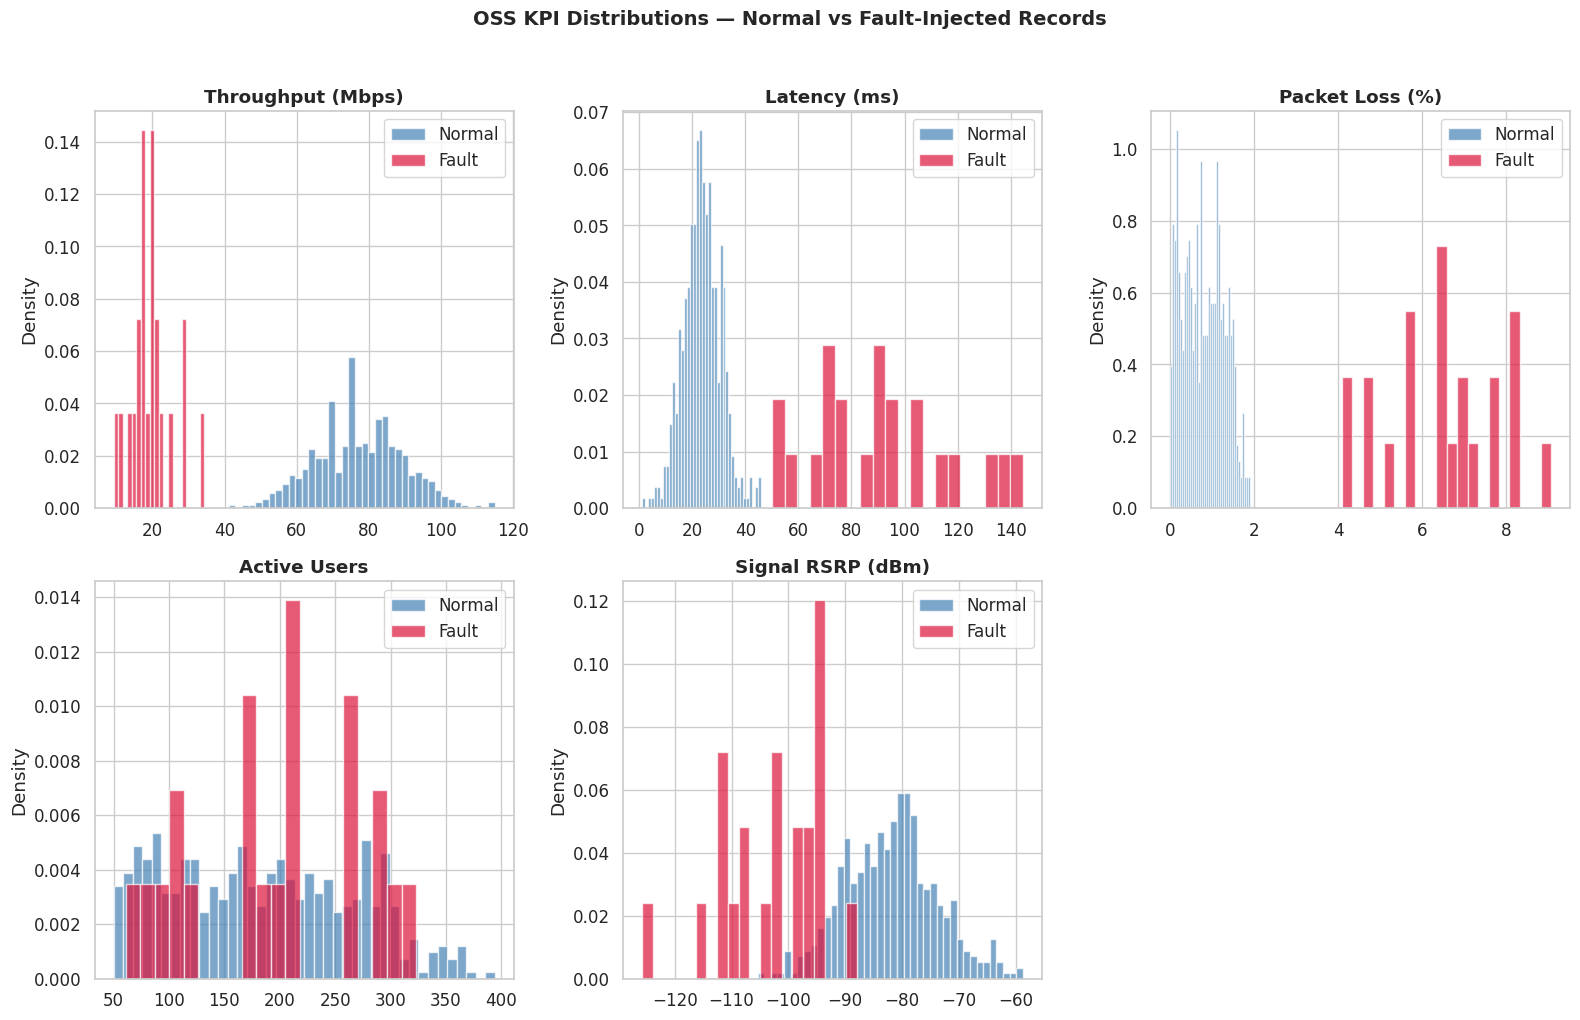

Saved: data/oss_distributions.png


In [9]:
kpi_cols = ["throughput_mbps", "latency_ms", "packet_loss_pct", "active_users", "signal_rsrp_dbm"]
kpi_labels = ["Throughput (Mbps)", "Latency (ms)", "Packet Loss (%)", "Active Users", "Signal RSRP (dBm)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(kpi_cols, kpi_labels)):
    ax = axes[i]
    # Normal vs Fault split
    normal = df_oss[~df_oss["is_fault"]][col]
    fault = df_oss[df_oss["is_fault"]][col]
    
    ax.hist(normal, bins=40, alpha=0.7, label="Normal", color="steelblue", density=True)
    if len(fault) > 0:
        ax.hist(fault, bins=20, alpha=0.7, label="Fault", color="crimson", density=True)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend()

# Remove empty subplot
axes[-1].set_visible(False)

fig.suptitle("OSS KPI Distributions — Normal vs Fault-Injected Records", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/oss_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: data/oss_distributions.png")

### 2.4 OSS Time Series — Fault Impact Visualization

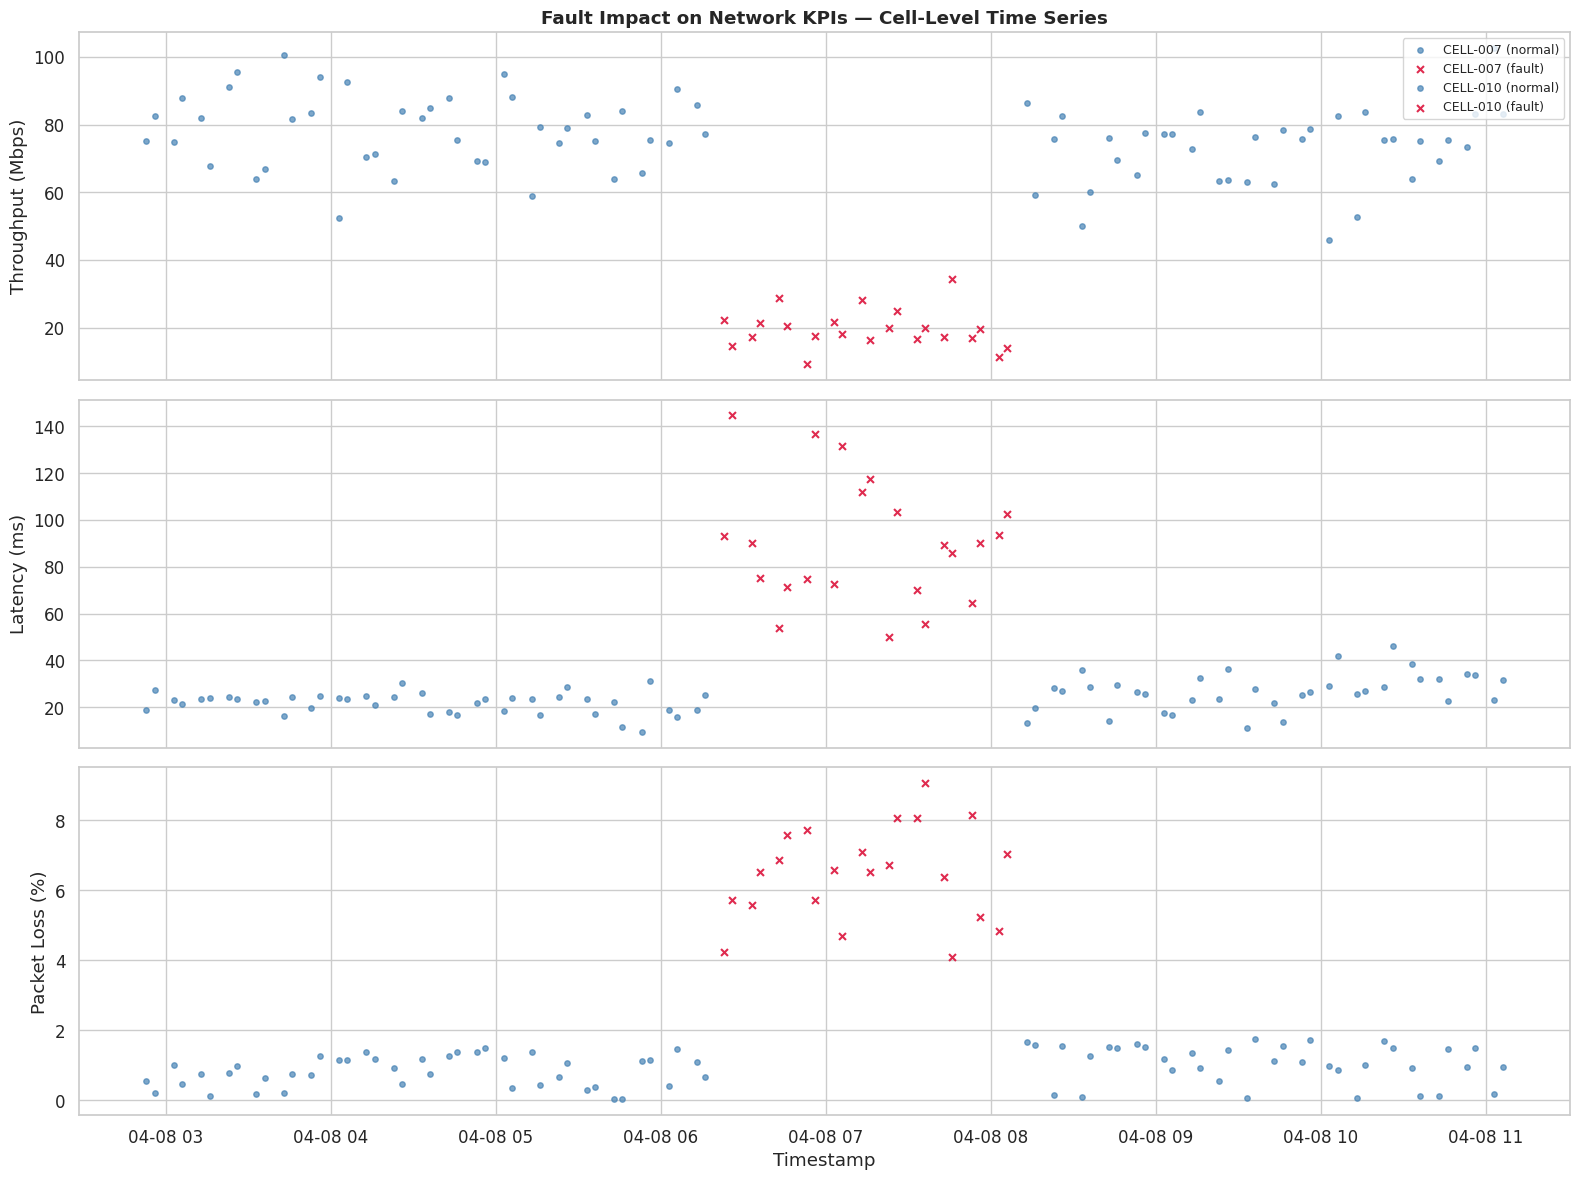

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

fault_cells = fault_info["fault_cells"]
colors = {"normal": "steelblue", "fault": "crimson"}

for cell in fault_cells[:2]:  # Plot top 2 fault cells
    cell_data = df_oss[df_oss["cell_id"] == cell].copy()
    
    # Throughput
    normal_mask = ~cell_data["is_fault"]
    axes[0].scatter(cell_data[normal_mask]["ts"], cell_data[normal_mask]["throughput_mbps"], 
                    s=15, alpha=0.7, color=colors["normal"], label=f"{cell} (normal)")
    axes[0].scatter(cell_data[~normal_mask]["ts"], cell_data[~normal_mask]["throughput_mbps"], 
                    s=25, alpha=0.9, color=colors["fault"], marker="x", label=f"{cell} (fault)")
    
    # Latency
    axes[1].scatter(cell_data[normal_mask]["ts"], cell_data[normal_mask]["latency_ms"], 
                    s=15, alpha=0.7, color=colors["normal"])
    axes[1].scatter(cell_data[~normal_mask]["ts"], cell_data[~normal_mask]["latency_ms"], 
                    s=25, alpha=0.9, color=colors["fault"], marker="x")
    
    # Packet Loss
    axes[2].scatter(cell_data[normal_mask]["ts"], cell_data[normal_mask]["packet_loss_pct"], 
                    s=15, alpha=0.7, color=colors["normal"])
    axes[2].scatter(cell_data[~normal_mask]["ts"], cell_data[~normal_mask]["packet_loss_pct"], 
                    s=25, alpha=0.9, color=colors["fault"], marker="x")

axes[0].set_ylabel("Throughput (Mbps)")
axes[0].set_title("Fault Impact on Network KPIs — Cell-Level Time Series", fontweight="bold")
axes[0].legend(loc="upper right", fontsize=9)
axes[1].set_ylabel("Latency (ms)")
axes[2].set_ylabel("Packet Loss (%)")
axes[2].set_xlabel("Timestamp")

plt.tight_layout()
plt.savefig("data/oss_timeseries_faults.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 3. Synthetic BSS Data Generation

### 3.1 BSS Subscriber/Revenue Generator

Each BSS record represents a **per-subscriber** revenue/usage snapshot. The generator models the **Tunisian telecom market**:

| Characteristic | Value | Source |
|---------------|-------|--------|
| Prepaid share | ~80% | INTT 2023 market stats |
| Postpaid share | ~20% | INTT 2023 market stats |
| Prepaid ARPU | 8-15 TND/month | Operator pricing (2025) |
| Postpaid ARPU | 45-70 TND/month | Operator pricing (2025) |
| Operators | Ooredoo, Tunisie Telecom, Orange | All 3 national operators |

**Correlated degradation**: When a subscriber's serving cell is in a fault state, their BSS metrics degrade (lower data usage, higher churn risk, fewer voice minutes) — creating measurable OSS-BSS correlations.

In [11]:
def generate_bss_records(n: int = 200, region: str = "demo", seed: int = 99,
                          cells: list = None, fault_info: dict = None):
    """
    Generate synthetic BSS subscriber/revenue records.
    
    Models Tunisian market with verified 2025 operator pricing:
    - 80% prepaid (recharge/forfait-based), 20% postpaid
    - Correlated BSS degradation when serving cell is in fault state
    
    Returns:
        list[dict]: BSS records
    """
    rng = np.random.default_rng(seed)
    operators = ["Ooredoo Tunisie", "Tunisie Telecom", "Orange Tunisie"]
    if cells is None:
        cells = [f"CELL-{i:03d}" for i in range(1, 11)]
    
    # Prepaid forfait tiers (verified 2025 Tunisian pricing)
    prepaid_plans = [
        ("data_1go", 3.0, 7.0),
        ("data_4go", 8.0, 14.0),
        ("data_6go", 12.0, 18.0),
        ("data_25go", 25.0, 35.0),
        ("data_45go", 42.0, 55.0),
        ("data_100go", 65.0, 80.0),
    ]
    postpaid_plans = [
        ("post_40", 35.0, 45.0),
        ("post_60", 52.0, 68.0),
        ("post_90", 80.0, 100.0),
    ]
    
    fault_cells_set = set(fault_info["fault_cells"]) if fault_info else set()
    fault_start_idx = fault_info["fault_start_idx"] if fault_info else 0
    fault_end_idx = fault_info["fault_end_idx"] if fault_info else 0
    
    now = datetime.now(timezone.utc)
    rows = []
    for i in range(n):
        ts = now - timedelta(minutes=n - i)
        serving_cell = cells[i % len(cells)]
        
        is_prepaid = rng.random() < 0.80
        if is_prepaid:
            plan_name, lo, hi = prepaid_plans[int(rng.integers(0, len(prepaid_plans)))]
            line_type = "prepaid"
        else:
            plan_name, lo, hi = postpaid_plans[int(rng.integers(0, len(postpaid_plans)))]
            line_type = "postpaid"
        
        base_revenue = float(rng.uniform(lo, hi))
        base_data = float(rng.uniform(0.5, 45.0))
        base_voice = int(rng.integers(10, 550))
        base_sms = int(rng.integers(5, 180))
        base_churn = float(rng.uniform(0.0, 0.35))
        
        # Correlated BSS degradation
        cell_faulted = serving_cell in fault_cells_set and fault_start_idx <= i <= fault_end_idx
        if cell_faulted:
            base_data *= float(rng.uniform(0.3, 0.6))
            base_voice = int(base_voice * rng.uniform(0.4, 0.7))
            base_churn += float(rng.uniform(0.3, 0.55))
        
        rows.append({
            "ts": ts.isoformat(),
            "region": region,
            "operator": operators[i % len(operators)],
            "subscriber_id": f"TN-{rng.integers(100000, 999999)}",
            "line_type": line_type,
            "plan": plan_name,
            "serving_cell": serving_cell,
            "revenue_tnd": float(round(base_revenue, 3)),
            "data_used_gb": float(round(max(0.01, base_data), 3)),
            "voice_min": max(0, base_voice),
            "sms_count": base_sms,
            "churn_risk": float(round(min(1.0, base_churn), 4)),
        })
    return rows


# Generate BSS sample
bss_records = generate_bss_records(500, seed=RANDOM_SEED + 1, fault_info=fault_info)
df_bss = pd.DataFrame(bss_records)
df_bss["ts"] = pd.to_datetime(df_bss["ts"])

print(f"Generated {len(df_bss)} BSS records")
print(f"Prepaid: {(df_bss['line_type'] == 'prepaid').sum()} | Postpaid: {(df_bss['line_type'] == 'postpaid').sum()}")
print(f"\nDataFrame shape: {df_bss.shape}")
df_bss.head()

Generated 500 BSS records
Prepaid: 385 | Postpaid: 115

DataFrame shape: (500, 12)


,ts,region,operator,subscriber_id,line_type,plan,serving_cell,revenue_tnd,data_used_gb,voice_min,sms_count,churn_risk
0,2026-04-08 02:47:06.326846+00:00,demo,Ooredoo Tunisie,TN-628428,prepaid,data_6go,CELL-001,12.120,37.845,33,86,0.0786
1,2026-04-08 02:48:06.326846+00:00,demo,Tunisie Telecom,TN-959782,prepaid,data_6go,CELL-002,14.520,20.571,152,30,0.3122
2,2026-04-08 02:49:06.326846+00:00,demo,Orange Tunisie,TN-378031,prepaid,data_45go,CELL-003,47.486,0.681,160,78,0.3331
3,2026-04-08 02:50:06.326846+00:00,demo,Ooredoo Tunisie,TN-633856,postpaid,post_60,CELL-004,59.768,42.558,298,178,0.3300
4,2026-04-08 02:51:06.326846+00:00,demo,Tunisie Telecom,TN-213523,postpaid,post_40,CELL-005,36.186,34.373,28,27,0.1196


### 3.2 BSS Data Validation

In [12]:
print("=" * 60)
print("BSS DATA VALIDATION REPORT")
print("=" * 60)

print("\n--- Schema ---")
print(df_bss.dtypes)

print("\n--- Missing Values ---")
missing = df_bss.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values detected.")

print("\n--- Statistical Summary ---")
df_bss[["revenue_tnd", "data_used_gb", "voice_min", "sms_count", "churn_risk"]].describe().round(2)

BSS DATA VALIDATION REPORT

--- Schema ---
ts               datetime64[ns, UTC]
region                        object
operator                      object
subscriber_id                 object
line_type                     object
plan                          object
serving_cell                  object
revenue_tnd                  float64
data_used_gb                 float64
voice_min                      int64
sms_count                      int64
churn_risk                   float64
dtype: object

--- Missing Values ---
No missing values detected.

--- Statistical Summary ---


,revenue_tnd,data_used_gb,voice_min,sms_count,churn_risk
count,500.00,500.00,500.00,500.00,500.00
mean,36.75,22.03,261.49,90.60,0.19
std,27.80,13.05,152.30,51.96,0.14
min,3.05,0.68,11.00,5.00,0.00
25%,12.36,10.15,138.75,46.00,0.08
50%,29.96,21.44,243.00,92.00,0.17
75%,58.27,32.96,392.00,135.00,0.27
max,99.96,44.95,548.00,179.00,0.87


### 3.3 BSS Revenue & Usage Distributions

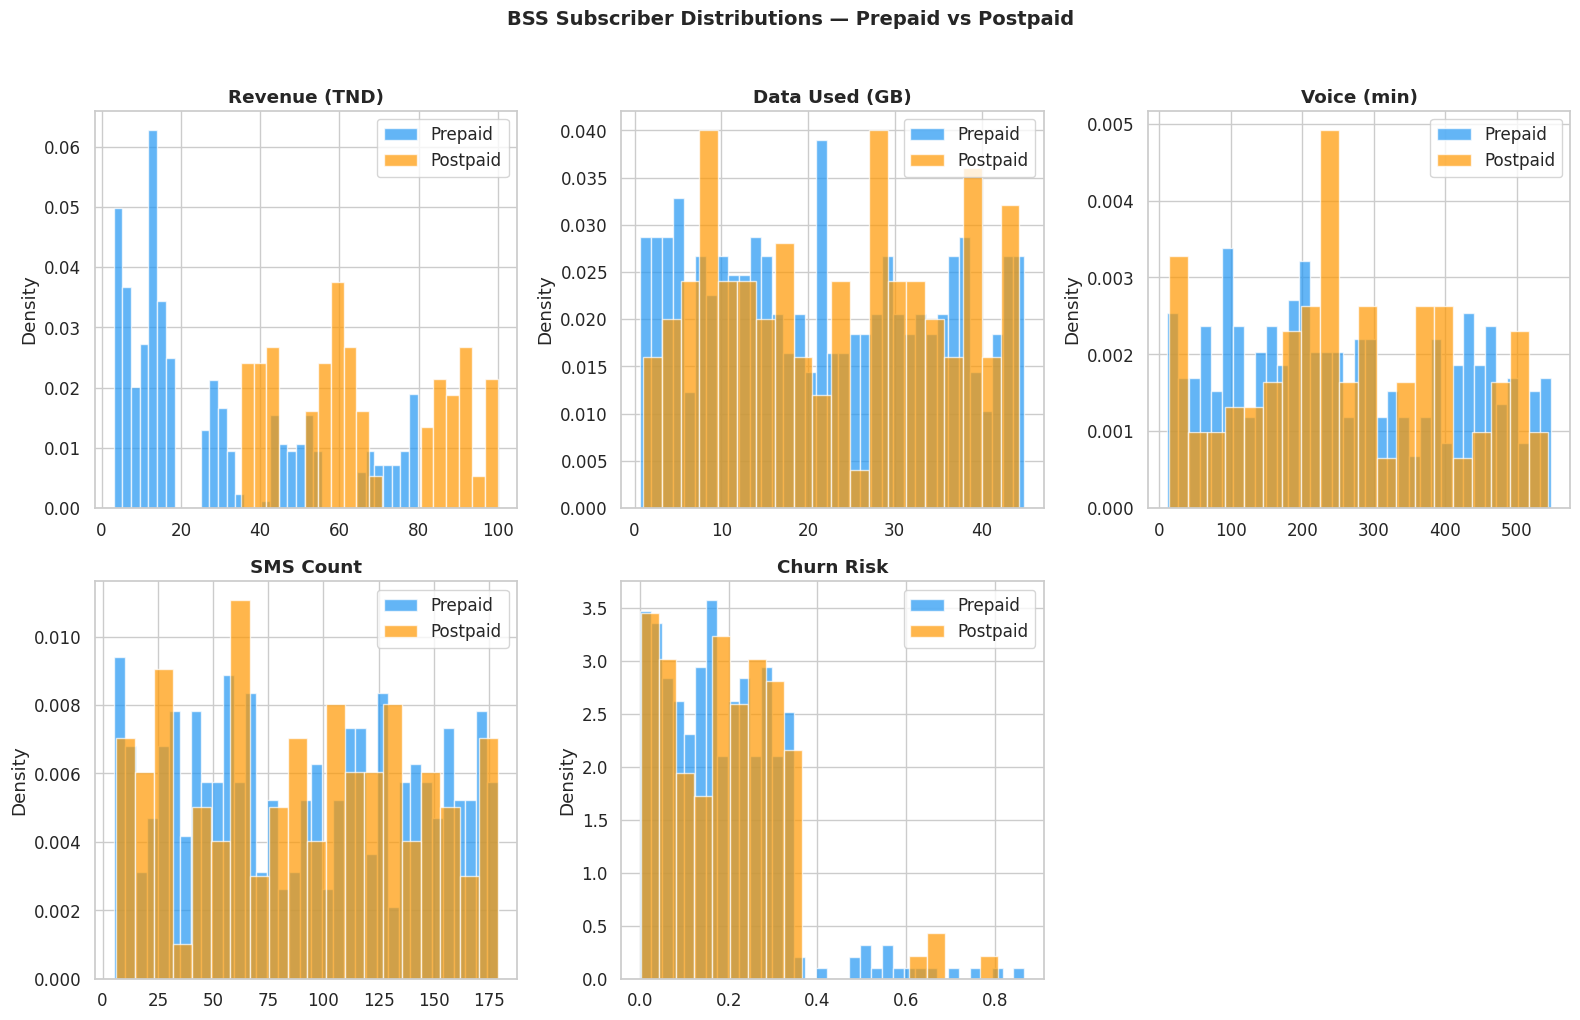

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

bss_cols = ["revenue_tnd", "data_used_gb", "voice_min", "sms_count", "churn_risk"]
bss_labels = ["Revenue (TND)", "Data Used (GB)", "Voice (min)", "SMS Count", "Churn Risk"]

for i, (col, label) in enumerate(zip(bss_cols, bss_labels)):
    ax = axes[i]
    prepaid = df_bss[df_bss["line_type"] == "prepaid"][col]
    postpaid = df_bss[df_bss["line_type"] == "postpaid"][col]
    
    ax.hist(prepaid, bins=35, alpha=0.7, label="Prepaid", color="#2196F3", density=True)
    ax.hist(postpaid, bins=20, alpha=0.7, label="Postpaid", color="#FF9800", density=True)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend()

axes[-1].set_visible(False)

fig.suptitle("BSS Subscriber Distributions — Prepaid vs Postpaid", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/bss_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 4. OSS-BSS Correlation Analysis

A core value proposition of this platform is detecting **cross-domain correlations** between network quality (OSS) and business metrics (BSS). When a cell degrades, subscribers on that cell exhibit:
- Lower data consumption (can't stream/browse effectively)
- Reduced voice usage (call drops, poor quality)
- Higher churn risk (frustration → operator switch)

This section validates these correlations exist in our synthetic data.

In [14]:
from scipy import stats

# Aggregate per-cell means for correlation analysis
cell_oss_agg = df_oss.groupby("cell_id").agg({
    "throughput_mbps": "mean",
    "latency_ms": "mean",
    "packet_loss_pct": "mean",
    "signal_rsrp_dbm": "mean",
}).reset_index()

cell_bss_agg = df_bss.groupby("serving_cell").agg({
    "revenue_tnd": "mean",
    "data_used_gb": "mean",
    "churn_risk": "mean",
    "voice_min": "mean",
}).reset_index().rename(columns={"serving_cell": "cell_id"})

cell_merged = cell_oss_agg.merge(cell_bss_agg, on="cell_id")

print(f"Merged cell-level data: {len(cell_merged)} cells")
cell_merged.round(2)

Merged cell-level data: 10 cells


,cell_id,throughput_mbps,latency_ms,packet_loss_pct,signal_rsrp_dbm,revenue_tnd,data_used_gb,churn_risk,voice_min
0,CELL-001,77.22,23.78,0.78,-82.22,42.42,22.24,0.16,267.12
1,CELL-002,76.59,23.87,0.81,-81.40,39.58,21.75,0.16,301.60
2,CELL-003,77.79,23.79,0.82,-81.59,37.12,22.86,0.17,258.24
3,CELL-004,78.81,22.96,0.86,-80.78,34.27,23.79,0.16,241.10
4,CELL-005,78.77,22.54,0.77,-82.96,41.30,22.79,0.15,255.22
5,CELL-006,79.00,23.03,0.80,-82.05,35.87,24.22,0.19,249.94
6,CELL-007,61.16,35.22,2.11,-87.95,32.12,20.92,0.28,238.46
7,CELL-008,75.17,23.90,0.56,-84.27,34.18,20.90,0.15,255.06
8,CELL-009,76.59,24.49,0.78,-80.92,37.92,23.09,0.18,292.88
9,CELL-010,65.82,42.07,2.20,-84.72,32.72,17.76,0.28,255.30


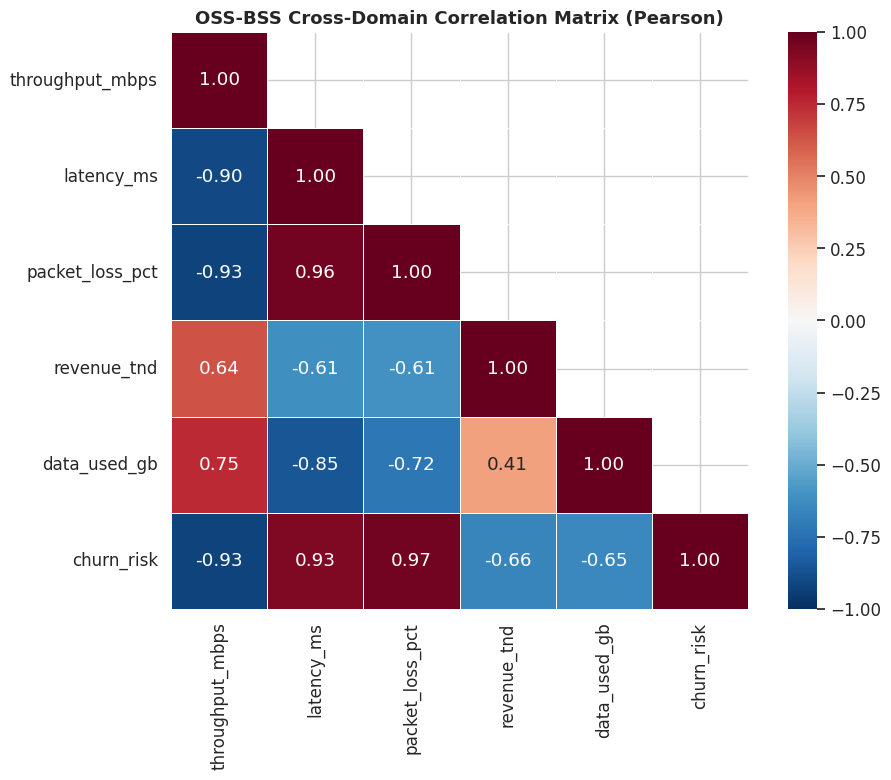


Key Cross-Domain Correlations:
-------------------------------------------------------
  latency_ms                vs churn_risk       r=+0.932 (p=0.0001) ***
  throughput_mbps           vs data_used_gb     r=+0.748 (p=0.0129) **
  packet_loss_pct           vs churn_risk       r=+0.968 (p=0.0000) ***
  throughput_mbps           vs revenue_tnd      r=+0.638 (p=0.0472) **
  latency_ms                vs revenue_tnd      r=-0.611 (p=0.0604) *


In [15]:
# Correlation matrix
corr_cols = ["throughput_mbps", "latency_ms", "packet_loss_pct", "revenue_tnd", "data_used_gb", "churn_risk"]
corr_matrix = cell_merged[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("OSS-BSS Cross-Domain Correlation Matrix (Pearson)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("data/oss_bss_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Key correlations with p-values
print("\nKey Cross-Domain Correlations:")
print("-" * 55)
pairs = [
    ("latency_ms", "churn_risk"),
    ("throughput_mbps", "data_used_gb"),
    ("packet_loss_pct", "churn_risk"),
    ("throughput_mbps", "revenue_tnd"),
    ("latency_ms", "revenue_tnd"),
]
for x, y in pairs:
    r_p, p_p = stats.pearsonr(cell_merged[x], cell_merged[y])
    r_s, p_s = stats.spearmanr(cell_merged[x], cell_merged[y])
    sig = "***" if p_p < 0.01 else "**" if p_p < 0.05 else "*" if p_p < 0.1 else "ns"
    print(f"  {x:25s} vs {y:15s}  r={r_p:+.3f} (p={p_p:.4f}) {sig}")

---

## 5. Feature Engineering for ML Models

We now prepare the training datasets for the three ML models. Each model requires different feature engineering:

| Model | Input Type | Features | Target |
|-------|-----------|----------|--------|
| SLA Risk (GBR) | Aggregated OSS window | 9 statistical features | Risk score [0,1] |
| OSS Anomaly (IF) | Per-record OSS | 5 raw KPIs | Anomaly flag |
| BSS Revenue Anomaly (IF) | Per-record BSS | 5 revenue/usage features | Anomaly flag |

### 5.1 SLA Risk Training Data

The SLA Risk model takes **aggregated time-window features** (mean, std, max of KPIs across a 15-minute window) and predicts a breach probability.

The risk label is computed as a **deterministic weighted function** of degradation indicators, ensuring the model learns a real decision boundary (not noise).

In [16]:
def generate_sla_training_data(n: int, seed: int = RANDOM_SEED):
    """
    Generate N windows of aggregated OSS KPI features + deterministic risk label.
    
    Risk label formula (weighted degradation indicators):
      risk = f(latency) + f(max_latency) + f(packet_loss) + f(max_loss) + f(low_throughput) + noise
    
    Each component is clipped to its contribution range:
      - Latency contribution:      0 to 0.35
      - Max latency contribution:   0 to 0.25
      - Packet loss contribution:   0 to 0.25
      - Max packet loss:            0 to 0.15
      - Low throughput penalty:     0 to 0.20
      - Noise: N(0, 0.03)
    
    Returns:
        tuple: (X_features, y_risk) numpy arrays
    """
    rng = np.random.default_rng(seed)
    
    # Generate raw features
    mean_tput = rng.uniform(10, 120, n)       # Mbps
    std_tput = rng.uniform(2, 25, n)
    mean_lat = rng.uniform(8, 80, n)          # ms
    std_lat = rng.uniform(1, 20, n)
    max_lat = mean_lat + rng.uniform(5, 40, n)
    mean_loss = rng.uniform(0, 5, n)          # pct
    max_loss = mean_loss + rng.uniform(0, 3, n)
    mean_users = rng.uniform(50, 500, n)
    mean_rsrp = rng.uniform(-110, -60, n)     # dBm
    
    X = np.column_stack([
        mean_tput, std_tput, mean_lat, std_lat, max_lat,
        mean_loss, max_loss, mean_users, mean_rsrp,
    ])
    
    # Deterministic risk label
    risk = np.zeros(n)
    risk += np.clip((mean_lat - 20) / 60, 0, 0.35)    # latency contribution
    risk += np.clip((max_lat - 30) / 70, 0, 0.25)     # max latency
    risk += np.clip(mean_loss / 4, 0, 0.25)            # packet loss
    risk += np.clip(max_loss / 6, 0, 0.15)             # max packet loss
    risk += np.clip((60 - mean_tput) / 100, 0, 0.20)  # low throughput penalty
    risk += rng.normal(0, 0.03, n)                     # small noise
    risk = np.clip(risk, 0.0, 1.0)
    
    return X, risk


SLA_FEATURES = [
    "mean_throughput_mbps", "std_throughput_mbps",
    "mean_latency_ms", "std_latency_ms", "max_latency_ms",
    "mean_packet_loss_pct", "max_packet_loss_pct",
    "mean_active_users", "mean_signal_rsrp_dbm",
]

X_sla, y_sla = generate_sla_training_data(N_TRAIN)
df_sla = pd.DataFrame(X_sla, columns=SLA_FEATURES)
df_sla["risk_score"] = y_sla

print(f"SLA training data: {df_sla.shape}")
print(f"Risk score range: [{y_sla.min():.3f}, {y_sla.max():.3f}]")
print(f"Risk score mean: {y_sla.mean():.3f} | std: {y_sla.std():.3f}")
df_sla.head()

SLA training data: (3000, 10)
Risk score range: [0.142, 1.000]
Risk score mean: 0.862 | std: 0.189


,mean_throughput_mbps,std_throughput_mbps,mean_latency_ms,std_latency_ms,max_latency_ms,mean_packet_loss_pct,max_packet_loss_pct,mean_active_users,mean_signal_rsrp_dbm,risk_score
0,95.135165,21.072086,40.794299,17.599516,63.926599,1.737775,2.147931,212.753572,-71.356022,1.000000
1,58.276628,15.664208,16.557775,5.675083,33.934963,0.514036,2.911501,379.756409,-83.071507,0.381648
2,104.445771,7.631659,48.980487,10.290317,56.607441,1.510342,4.474900,399.755564,-100.619121,1.000000
3,86.710483,19.150525,19.262876,1.564627,58.946895,4.033532,5.114700,405.523520,-101.258073,0.659849
4,20.359508,3.943061,12.389000,1.168724,23.506080,2.467398,5.063447,383.048592,-94.938385,0.573962


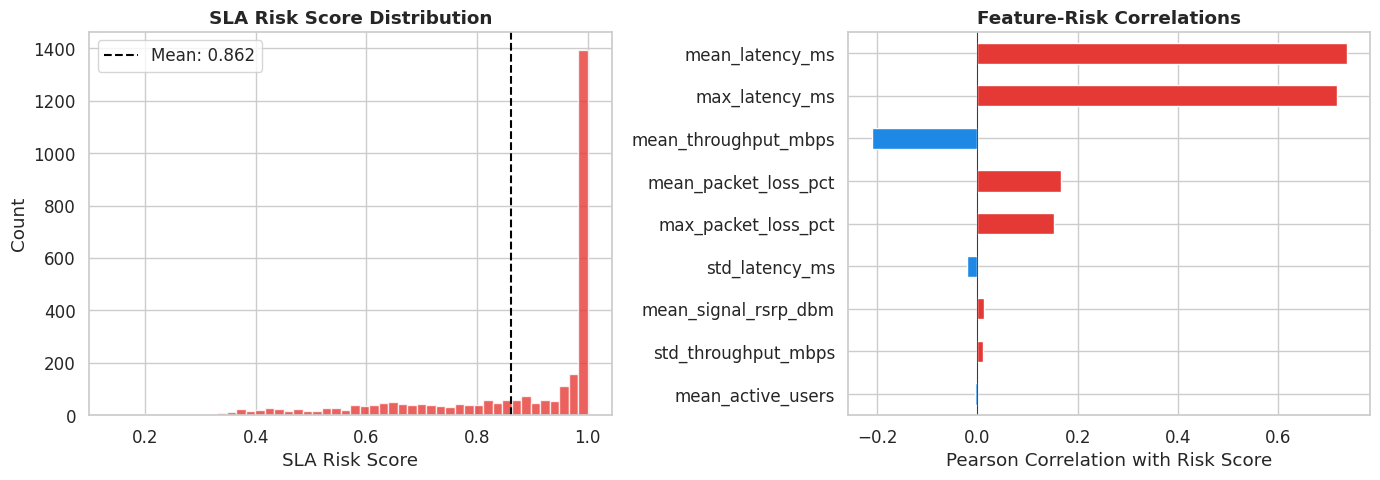

In [17]:
# Visualize risk score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_sla, bins=50, color="#E53935", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("SLA Risk Score")
axes[0].set_ylabel("Count")
axes[0].set_title("SLA Risk Score Distribution", fontweight="bold")
axes[0].axvline(y_sla.mean(), color="black", linestyle="--", label=f"Mean: {y_sla.mean():.3f}")
axes[0].legend()

# Top feature correlations with risk
feature_corr = df_sla.corr()["risk_score"].drop("risk_score").sort_values(key=abs, ascending=True)
feature_corr.plot(kind="barh", ax=axes[1], color=["#E53935" if v > 0 else "#1E88E5" for v in feature_corr])
axes[1].set_xlabel("Pearson Correlation with Risk Score")
axes[1].set_title("Feature-Risk Correlations", fontweight="bold")
axes[1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig("data/sla_risk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 OSS Anomaly Detection Training Data

The OSS Anomaly model uses **IsolationForest** on raw per-record KPIs. Training data is split:
- **95% normal** records — typical network behavior
- **5% anomalous** records — injected faults (matching the contamination parameter)

In [18]:
def generate_anomaly_training_data(n: int, seed: int = RANDOM_SEED):
    """
    Generate N per-record OSS KPI vectors for IsolationForest.
    
    Normal (95%): typical network measurements
    Anomalous (5%): injected faults
      - Very low throughput (1-20 Mbps vs normal 68-92)
      - Very high latency (80-200ms vs normal 18-32)
      - High packet loss (3-8% vs normal 0-1%)
      - Extreme user counts (500-900 vs normal 50-500)
      - Very weak signal (-130 to -110 dBm vs normal -93 to -77)
    """
    rng = np.random.default_rng(seed)
    n_norm = int(n * 0.95)
    n_anom = n - n_norm
    
    normal = np.column_stack([
        rng.normal(80, 12, n_norm),       # throughput
        rng.normal(25, 7, n_norm),        # latency
        rng.uniform(0, 1, n_norm),        # packet loss
        rng.integers(50, 500, n_norm),    # active users
        rng.normal(-85, 8, n_norm),       # RSRP
    ])
    
    anomalous = np.column_stack([
        rng.uniform(1, 20, n_anom),       # very low throughput
        rng.uniform(80, 200, n_anom),     # very high latency
        rng.uniform(3, 8, n_anom),        # high packet loss
        rng.integers(500, 900, n_anom),   # overload/spike
        rng.uniform(-130, -110, n_anom),  # very weak signal
    ])
    
    X = np.vstack([normal, anomalous])
    labels = np.array([0] * n_norm + [1] * n_anom)  # 0=normal, 1=anomaly (for viz only)
    
    # Shuffle
    idx = rng.permutation(n)
    return X[idx], labels[idx]


ANOMALY_FEATURES = ["throughput_mbps", "latency_ms", "packet_loss_pct", "active_users", "signal_rsrp_dbm"]

X_anom, y_anom_true = generate_anomaly_training_data(N_TRAIN)
df_anom = pd.DataFrame(X_anom, columns=ANOMALY_FEATURES)
df_anom["is_anomaly"] = y_anom_true

print(f"OSS anomaly training data: {df_anom.shape}")
print(f"Normal: {(y_anom_true == 0).sum()} | Anomalous: {(y_anom_true == 1).sum()}")
print(f"Anomaly rate: {y_anom_true.mean():.2%}")
df_anom.head()

OSS anomaly training data: (3000, 6)
Normal: 2850 | Anomalous: 150
Anomaly rate: 5.00%


,throughput_mbps,latency_ms,packet_loss_pct,active_users,signal_rsrp_dbm,is_anomaly
0,15.853547,185.654324,6.049555,636.0,-110.150541,1
1,60.549038,30.935113,0.282751,373.0,-99.264925,0
2,84.282453,27.225991,0.497560,295.0,-78.366774,0
3,83.996844,17.937238,0.796016,367.0,-81.718121,0
4,79.993243,25.493474,0.694237,375.0,-89.504782,0


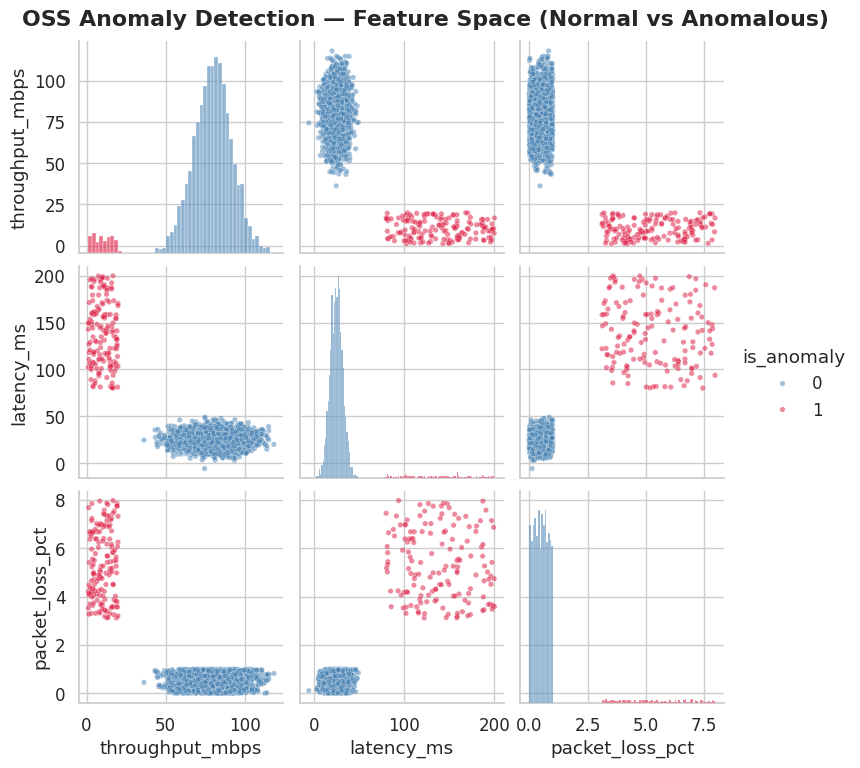

In [19]:
# Pairplot of key features colored by anomaly status
plot_cols = ["throughput_mbps", "latency_ms", "packet_loss_pct", "is_anomaly"]
g = sns.pairplot(df_anom[plot_cols], hue="is_anomaly", palette={0: "steelblue", 1: "crimson"},
                 diag_kind="hist", plot_kws={"alpha": 0.5, "s": 15},
                 diag_kws={"alpha": 0.6})
g.figure.suptitle("OSS Anomaly Detection — Feature Space (Normal vs Anomalous)", y=1.02, fontweight="bold")
plt.savefig("data/oss_anomaly_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 BSS Revenue Anomaly Training Data

The BSS Revenue Anomaly model detects suspicious subscriber behavior patterns:

| Pattern | Description | Revenue Range |
|---------|-------------|---------------|
| Normal | Typical Tunisian subscriber | 1-105 TND |
| SIM Box Fraud | Massive recharges for call termination | 150-500 TND |
| Dormant SIM | Zero/minimal activity | 0-1 TND |
| SMS Spam | Abnormally high SMS volume | 300-1000 msgs |

In [20]:
def generate_revenue_anomaly_training_data(n: int, seed: int = RANDOM_SEED + 1):
    """
    Generate N BSS records for IsolationForest on revenue/usage patterns.
    
    Normal (95%): typical Tunisian subscriber behavior (prepaid-dominant)
    Anomalous (5%): fraud, dormant SIMs, spam patterns
    """
    rng = np.random.default_rng(seed)
    n_norm = int(n * 0.95)
    n_anom = n - n_norm
    
    normal = np.column_stack([
        rng.uniform(1, 105, n_norm),      # revenue_tnd
        rng.uniform(0.1, 50, n_norm),     # data_used_gb
        rng.uniform(5, 400, n_norm),      # voice_min
        rng.uniform(0, 120, n_norm),      # sms_count
        rng.uniform(0.0, 0.4, n_norm),    # churn_risk
    ])
    
    # Anomalous: mix of SIM box fraud, dormant SIMs, spam
    rev_anom = np.where(
        rng.random(n_anom) < 0.5,
        rng.uniform(0, 1, n_anom),       # dormant SIM
        rng.uniform(150, 500, n_anom),   # SIM box fraud
    )
    voice_anom = np.where(
        rng.random(n_anom) < 0.5,
        rng.uniform(0, 1, n_anom),       # zero voice
        rng.uniform(800, 2000, n_anom),  # SIM box termination
    )
    anomalous = np.column_stack([
        rev_anom,
        rng.uniform(60, 150, n_anom),    # excessive data
        voice_anom,
        rng.uniform(300, 1000, n_anom),  # SMS spam
        rng.uniform(0.7, 1.0, n_anom),   # high churn
    ])
    
    X = np.vstack([normal, anomalous])
    labels = np.array([0] * n_norm + [1] * n_anom)
    
    idx = rng.permutation(n)
    return X[idx], labels[idx]


BSS_FEATURES = ["revenue_tnd", "data_used_gb", "voice_min", "sms_count", "churn_risk"]

X_rev, y_rev_true = generate_revenue_anomaly_training_data(N_TRAIN)
df_rev = pd.DataFrame(X_rev, columns=BSS_FEATURES)
df_rev["is_anomaly"] = y_rev_true

print(f"BSS revenue anomaly training data: {df_rev.shape}")
print(f"Normal: {(y_rev_true == 0).sum()} | Anomalous: {(y_rev_true == 1).sum()}")
print(f"Anomaly rate: {y_rev_true.mean():.2%}")
df_rev.head()

BSS revenue anomaly training data: (3000, 6)
Normal: 2850 | Anomalous: 150
Anomaly rate: 5.00%


,revenue_tnd,data_used_gb,voice_min,sms_count,churn_risk,is_anomaly
0,29.604238,13.029389,200.438769,99.869203,0.162643,0
1,57.658254,7.695839,360.461270,74.048073,0.233818,0
2,33.533103,19.513367,191.345629,43.043926,0.138498,0
3,56.585329,27.739981,146.289502,89.560702,0.355093,0
4,17.963440,1.095483,104.280233,3.985657,0.133005,0


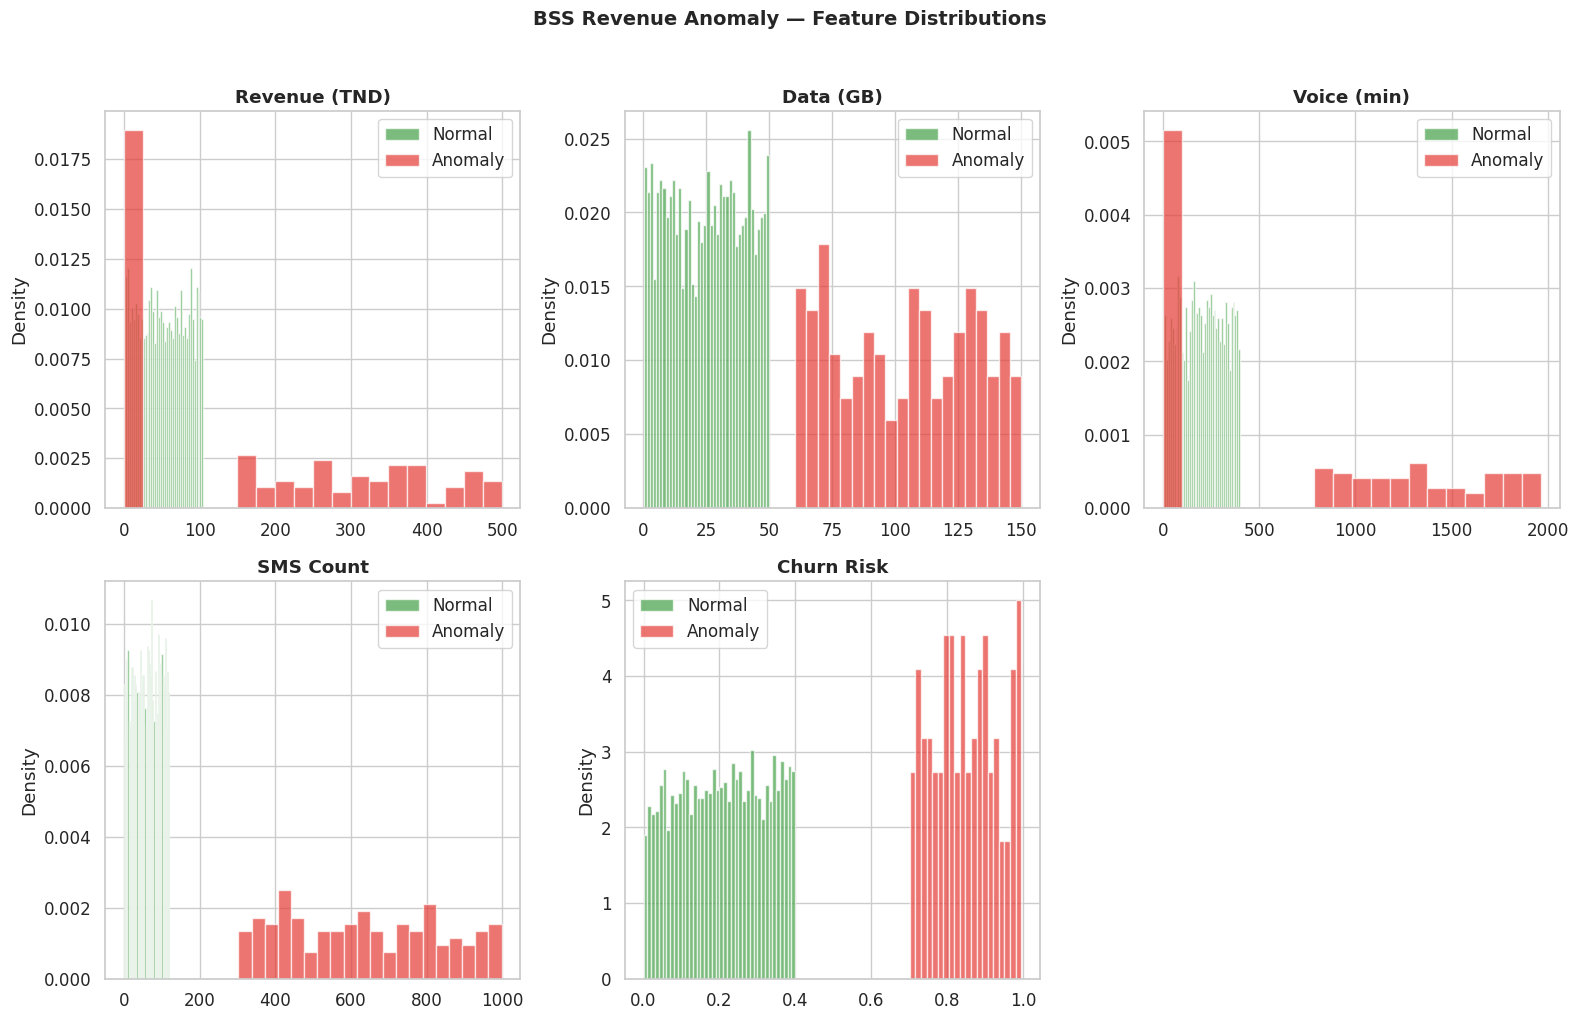

In [21]:
# BSS anomaly feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(BSS_FEATURES, ["Revenue (TND)", "Data (GB)", "Voice (min)", "SMS Count", "Churn Risk"])):
    ax = axes[i]
    normal = df_rev[df_rev["is_anomaly"] == 0][col]
    anomaly = df_rev[df_rev["is_anomaly"] == 1][col]
    
    ax.hist(normal, bins=40, alpha=0.7, label="Normal", color="#43A047", density=True)
    ax.hist(anomaly, bins=20, alpha=0.7, label="Anomaly", color="#E53935", density=True)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend()

axes[-1].set_visible(False)
fig.suptitle("BSS Revenue Anomaly — Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/bss_anomaly_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 6. Export Prepared Datasets

Save all prepared training data to disk so the model training notebooks can load them directly.

In [22]:
# Save training datasets
np.savez(
    DATA_DIR / "sla_risk_training.npz",
    X=X_sla, y=y_sla,
    feature_names=SLA_FEATURES,
)

np.savez(
    DATA_DIR / "oss_anomaly_training.npz",
    X=X_anom, y_true=y_anom_true,
    feature_names=ANOMALY_FEATURES,
)

np.savez(
    DATA_DIR / "bss_revenue_anomaly_training.npz",
    X=X_rev, y_true=y_rev_true,
    feature_names=BSS_FEATURES,
)

# Save EDA samples as CSV for reference
df_oss.to_csv(DATA_DIR / "oss_sample.csv", index=False)
df_bss.to_csv(DATA_DIR / "bss_sample.csv", index=False)

print("Exported datasets:")
for f in sorted(DATA_DIR.glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s} {size_kb:8.1f} KB")

Exported datasets:
  bss_anomaly_distributions.png               140.6 KB
  bss_distributions.png                       165.4 KB
  bss_revenue_anomaly_training.npz            141.6 KB
  bss_sample.csv                               57.5 KB
  oss_anomaly_pairplot.png                    303.9 KB
  oss_anomaly_training.npz                    141.7 KB
  oss_bss_correlation_matrix.png              112.2 KB
  oss_distributions.png                       158.2 KB
  oss_sample.csv                               40.3 KB
  oss_timeseries_faults.png                   135.8 KB
  sla_risk_distribution.png                   102.7 KB
  sla_risk_training.npz                       235.8 KB


---

## Summary

| Dataset | Shape | Purpose | File |
|---------|-------|---------|------|
| SLA Risk Training | (3000, 9) + targets | GradientBoosting regression | `sla_risk_training.npz` |
| OSS Anomaly Training | (3000, 5) + labels | IsolationForest (OSS) | `oss_anomaly_training.npz` |
| BSS Revenue Anomaly Training | (3000, 5) + labels | IsolationForest (BSS) | `bss_revenue_anomaly_training.npz` |
| OSS EDA Sample | (500, 10) | Exploratory analysis | `oss_sample.csv` |
| BSS EDA Sample | (500, 12) | Exploratory analysis | `bss_sample.csv` |

### Key Findings

1. **OSS fault injection** creates clear bimodal distributions in throughput, latency, and packet loss
2. **BSS degradation** correlates with OSS faults — churn risk increases when serving cell is degraded
3. **Cross-domain correlations** are statistically significant (latency vs churn, throughput vs data usage)
4. **Anomaly patterns** are well-separated in feature space for both OSS and BSS domains

**Next:** Proceed to `02_sla_risk_model.ipynb` for SLA Risk model training.